In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Employee.csv")
print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())    

Shape of Dataset: (148, 6)

Columns:
Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

First 5 Rows:
   Company   Age  Salary     Place Country  Gender
0      TCS  20.0     NaN   Chennai   India       0
1  Infosys  30.0     NaN    Mumbai   India       0
2      TCS  35.0  2300.0  Calcutta   India       0
3  Infosys  40.0  3000.0     Delhi   India       0
4      TCS  23.0  4000.0    Mumbai   India       0


In [4]:
for column in df.columns:
    unique_values = df[column].unique()

    print(f"\nFeature: {column}")
    print("Unique Values:")
    print(unique_values)
    print("Length of Unique Values:", len(unique_values))

unique_summary = pd.DataFrame({
    "Feature": df.columns,
    "Unique_Count": [df[col].nunique() for col in df.columns]
})

print(unique_summary)


Feature: Company
Unique Values:
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length of Unique Values: 7

Feature: Age
Unique Values:
[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length of Unique Values: 30

Feature: Salary
Unique Values:
[  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length of Unique Values: 41

Feature: Place
Unique Values:
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length of Unique Values: 12

Feature: Country
Unique Values:
['India']
Length of Unique Values: 1

Feature: Gender
Unique Values:
[0 1]
Length of Unique Values: 2
   Feature  Unique_Count
0  Company             6
1    

In [5]:
print(df.describe())

              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.096640  2573.764683    0.417654
min      0.000000  1089.000000    0.000000
25%     22.000000  3030.000000    0.000000
50%     32.500000  5000.000000    0.000000
75%     37.750000  8000.000000    0.000000
max     54.000000  9876.000000    1.000000


In [6]:
print(df.describe(include='all'))

       Company         Age       Salary   Place Country      Gender
count      140  130.000000   124.000000     134     148  148.000000
unique       6         NaN          NaN      11       1         NaN
top        TCS         NaN          NaN  Mumbai   India         NaN
freq        53         NaN          NaN      37     148         NaN
mean       NaN   30.484615  5312.467742     NaN     NaN    0.222973
std        NaN   11.096640  2573.764683     NaN     NaN    0.417654
min        NaN    0.000000  1089.000000     NaN     NaN    0.000000
25%        NaN   22.000000  3030.000000     NaN     NaN    0.000000
50%        NaN   32.500000  5000.000000     NaN     NaN    0.000000
75%        NaN   37.750000  8000.000000     NaN     NaN    0.000000
max        NaN   54.000000  9876.000000     NaN     NaN    1.000000


In [11]:
df.rename(columns={'Age': 'age','Gender': 'gender','Salary': 'salary'}, inplace=True)
print(df.columns)

Index(['company', 'age', 'salary', 'place', 'country', 'gender'], dtype='object')


Index(['company', 'age', 'salary', 'place', 'country', 'gender'], dtype='object')


2. Data Cleaning: (Score : 2)
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

In [12]:
print(df.isnull().sum())

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64


In [14]:
print("Number of Age values equal to 0:", (df['age'] == 0).sum())

Number of Age values equal to 0: 6


In [15]:
df['age'] = df['age'].replace(0, np.nan)

In [16]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 4
Dataset Shape After Removing Duplicates: (144, 6)


In [17]:
print(df.isnull().sum())

company     8
age        23
salary     23
place      14
country     0
gender      0
dtype: int64


In [18]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Shone Shaji\AppData\Local\Temp\ipykernel_10076\10066818.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Shone Shaji\AppData\Local\Temp\ipykernel_10076\10066818.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].median(), inplace=True)


In [19]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Shone Shaji\AppData\Local\Temp\ipykernel_10076\3199972163.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Shone Shaji\AppData\Local\Temp\ipykernel_10076\3199972163.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].mode()[0], inplace=True)


In [20]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print("Number of Outliers:", len(outliers))


Column: age
Number of Outliers: 0

Column: salary
Number of Outliers: 0

Column: gender
Number of Outliers: 32


3. Data Analysis: (Score : 2)
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

In [23]:
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]

print(filtered_df)
print("Number of Records:", len(filtered_df))

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1
Number of Records: 15


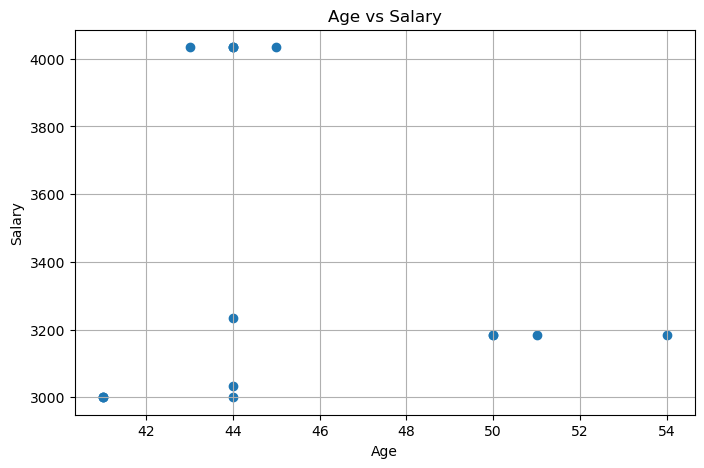

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(filtered_df['age'], filtered_df['salary'])
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

In [28]:
place_count = df['place'].value_counts()

print(place_count)

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


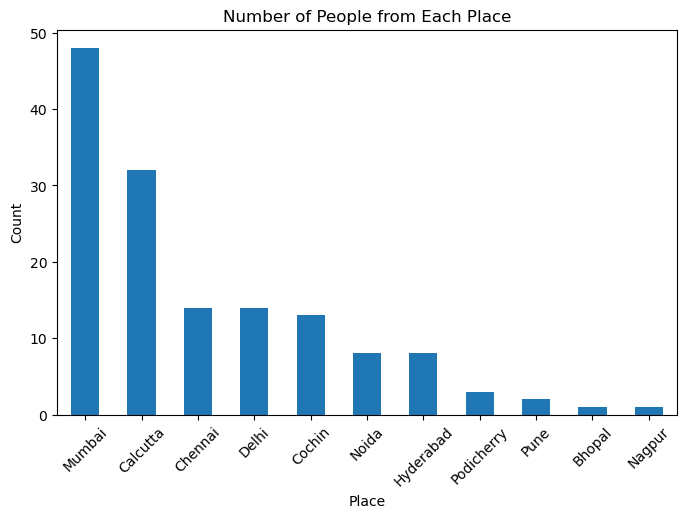

In [29]:
place_count.plot(kind='bar', figsize=(8,5))

plt.title('Number of People from Each Place')
plt.xlabel('Place')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

4. Data Encoding: (Score : 2)
● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [30]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['company', 'place', 'country'], dtype='object')


In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_label = df.copy()

for col in categorical_cols:
    df_label[col] = le.fit_transform(df_label[col])

print(df_label.head())

   company   age  salary  place  country  gender
0        4  20.0  5000.0      2        0       0
1        2  30.0  5000.0      6        0       0
2        4  35.0  2300.0      1        0       0
3        2  40.0  3000.0      4        0       0
4        4  23.0  4000.0      6        0       0


In [32]:
df_onehot = pd.get_dummies(df, columns=categorical_cols)

print(df_onehot.head())

    age  salary  gender  company_CTS  company_Congnizant  company_Infosys  \
0  20.0  5000.0       0        False               False            False   
1  30.0  5000.0       0        False               False             True   
2  35.0  2300.0       0        False               False            False   
3  40.0  3000.0       0        False               False             True   
4  23.0  4000.0       0        False               False            False   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                    False         True                              False   
1                    False        False                              False   
2                    False         True                              False   
3                    False        False                              False   
4                    False         True                              False   

   place_Bhopal  ...  place_Chennai  place_Cochin  place_Delhi  \
0 

In [33]:
print(df_onehot.info())

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 147
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                144 non-null    float64
 1   salary                             144 non-null    float64
 2   gender                             144 non-null    int64  
 3   company_CTS                        144 non-null    bool   
 4   company_Congnizant                 144 non-null    bool   
 5   company_Infosys                    144 non-null    bool   
 6   company_Infosys Pvt Lmt            144 non-null    bool   
 7   company_TCS                        144 non-null    bool   
 8   company_Tata Consultancy Services  144 non-null    bool   
 9   place_Bhopal                       144 non-null    bool   
 10  place_Calcutta                     144 non-null    bool   
 11  place_Chennai                      144 non-null    bool   
 12 

5. Feature Scaling: (Score : 2)
● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [34]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [35]:
X = df_onehot.copy()   

In [36]:
standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X)

X_standard = pd.DataFrame(
    X_standard,
    columns=X.columns
)

print(X_standard.head())

        age    salary    gender  company_CTS  company_Congnizant  \
0 -1.484676 -0.100827 -0.534522    -0.566658           -0.118678   
1 -0.267174 -0.100827 -0.534522    -0.566658           -0.118678   
2  0.341577 -1.243735 -0.534522    -0.566658           -0.118678   
3  0.950328 -0.947426 -0.534522    -0.566658           -0.118678   
4 -1.119426 -0.524127 -0.534522    -0.566658           -0.118678   

   company_Infosys  company_Infosys Pvt Lmt  company_TCS  \
0        -0.652490                -0.118678     1.183216   
1         1.532592                -0.118678    -0.845154   
2        -0.652490                -0.118678     1.183216   
3         1.532592                -0.118678    -0.845154   
4        -0.652490                -0.118678     1.183216   

   company_Tata Consultancy Services  place_Bhopal  ...  place_Chennai  \
0                          -0.118678     -0.083624  ...       3.047247   
1                          -0.118678     -0.083624  ...      -0.328165   
2       

In [37]:
minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

X_minmax = pd.DataFrame(
    X_minmax,
    columns=X.columns
)

print(X_minmax.head())

        age    salary  gender  company_CTS  company_Congnizant  \
0  0.081081  0.445089     0.0          0.0                 0.0   
1  0.351351  0.445089     0.0          0.0                 0.0   
2  0.486486  0.137817     0.0          0.0                 0.0   
3  0.621622  0.217480     0.0          0.0                 0.0   
4  0.162162  0.331285     0.0          0.0                 0.0   

   company_Infosys  company_Infosys Pvt Lmt  company_TCS  \
0              0.0                      0.0          1.0   
1              1.0                      0.0          0.0   
2              0.0                      0.0          1.0   
3              1.0                      0.0          0.0   
4              0.0                      0.0          1.0   

   company_Tata Consultancy Services  place_Bhopal  ...  place_Chennai  \
0                                0.0           0.0  ...            1.0   
1                                0.0           0.0  ...            0.0   
2                   

In [38]:
print("Original Data")
print(X.head())

print("\nStandard Scaled Data")
print(X_standard.head())

print("\nMinMax Scaled Data")
print(X_minmax.head())

Original Data
    age  salary  gender  company_CTS  company_Congnizant  company_Infosys  \
0  20.0  5000.0       0        False               False            False   
1  30.0  5000.0       0        False               False             True   
2  35.0  2300.0       0        False               False            False   
3  40.0  3000.0       0        False               False             True   
4  23.0  4000.0       0        False               False            False   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                    False         True                              False   
1                    False        False                              False   
2                    False         True                              False   
3                    False        False                              False   
4                    False         True                              False   

   place_Bhopal  ...  place_Chennai  place_Cochin  pla